# Scored TOPs: exploration

Read-only look at the TOP model's output on the full corpus: how many TOPs per protocol, how long
they are, where the model finds no opener, and spot checks of outliers.

Inputs: `top_openers_<model>_since_<date>.parquet` (score_corpus.py), `top_segments_` and
`tops_since_<date>.parquet` (build_top_segments.py).

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "../..")
from utils.colors import NAVY, GOLD

MODEL, SINCE = "g0_block_cv_pool", "2009-09-29"
SEED = 20261003

R = os.environ["DATA_ROOT"]
blocks = pd.read_parquet(f"{R}/measurement/top_change/top_openers_{MODEL}_since_{SINCE}.parquet")
tops = pd.read_parquet(f"{R}/processed/tops_since_{SINCE}.parquet", columns=["top_id", "protocol_id", "state", "date", "top_seq", "n_words"])
segments = pd.read_parquet(f"{R}/processed/top_segments_since_{SINCE}.parquet", columns=["paragraph_id", "protocol_id", "protocol_position", "top_seq"])
urls = pd.read_parquet(f"{R}/raw/stateparl_v3_parquet/stateparl_v3_protocols.parquet", columns=["protocol_id", "url"]).set_index("protocol_id")["url"]
tops["year"] = pd.to_datetime(tops["date"]).dt.year
real = tops[tops["top_seq"] > 0]
print(f"{blocks['protocol_id'].nunique():,} protocols, {len(blocks):,} chair blocks, {blocks['is_opener_pred'].sum():,} openers, {len(real):,} TOPs")

6,094 protocols, 636,021 chair blocks, 73,012 openers, 73,012 TOPs


## TOPs per protocol

Segment 0 (before the first opener) does not count as a TOP. Protocols without any opener count as 0.

count    6179.0
mean       11.8
std         6.7
min         0.0
25%         7.0
50%        11.0
75%        16.0
max        78.0


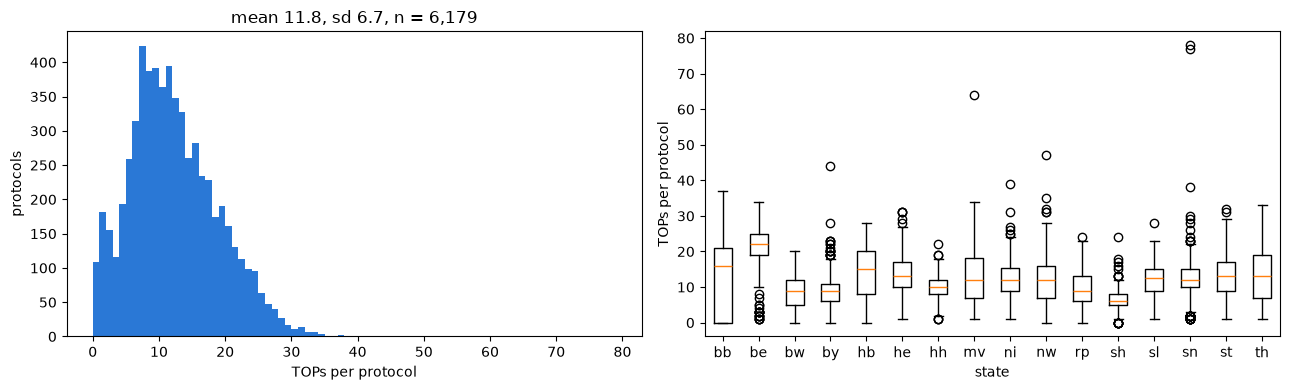

,count,mean,std,median,min,max
state,,,,,,
bb,312,12.9,10.7,16.0,0,37
be,279,21.3,6.3,22.0,1,34
bw,471,8.7,4.2,9.0,0,20
by,464,8.9,4.6,9.0,0,44
hb,274,13.9,6.8,15.0,0,28
he,479,13.6,5.4,13.0,1,31
hh,334,10.1,3.3,10.0,1,22
mv,424,13.4,7.9,12.0,1,64
ni,472,12.4,4.7,12.0,1,39


In [2]:
protocol_state = tops.drop_duplicates("protocol_id").set_index("protocol_id")["state"]
per = real.groupby("protocol_id").size().reindex(protocol_state.index, fill_value=0)
print(per.describe().round(1).to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(per, bins=range(0, per.max() + 2), color=NAVY)
ax[0].set(xlabel="TOPs per protocol", ylabel="protocols", title=f"mean {per.mean():.1f}, sd {per.std():.1f}, n = {len(per):,}")
by_state = per.groupby(protocol_state)
ax[1].boxplot([g.to_numpy() for _, g in by_state], tick_labels=list(by_state.groups))
ax[1].set(xlabel="state", ylabel="TOPs per protocol")
plt.tight_layout(); plt.show()
by_state.agg(["count", "mean", "std", "median", "min", "max"]).round(1)

Mean TOPs per protocol by year. A jump within a state can mean a change in protocol format rather than in parliamentary practice.

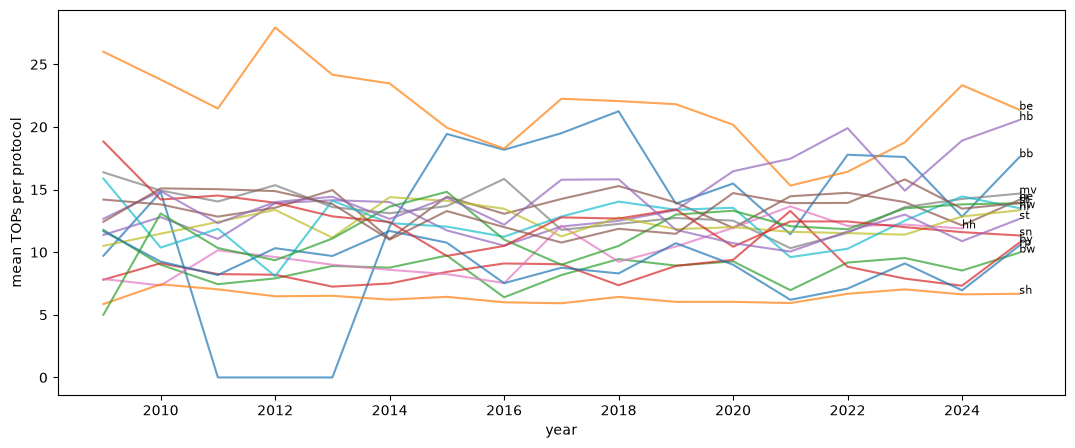

In [3]:
per_year = (per.rename("n_tops").to_frame().join(tops.drop_duplicates("protocol_id").set_index("protocol_id")[["state", "year"]])
            .groupby(["year", "state"])["n_tops"].mean().unstack())
ax = per_year.plot(figsize=(13, 5), legend=False, alpha=.7)
for state in per_year:
    last = per_year[state].dropna()
    ax.annotate(state, (last.index[-1], last.iloc[-1]), fontsize=8)
ax.set(ylabel="mean TOPs per protocol"); plt.show()

## TOP length

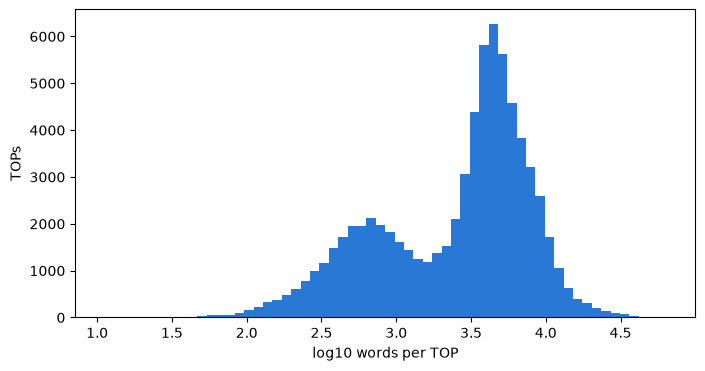

count    73012.0
mean      4115.0
std       3934.0
min         11.0
25%        956.0
50%       3591.0
75%       5627.0
max      64616.0
TOPs under 100 words: 349 (0.5%)


state
hb    0.000
by    0.000
hh    0.000
sl    0.000
ni    0.002
th    0.003
st    0.003
be    0.003
bw    0.004
mv    0.005
sh    0.005
bb    0.005
rp    0.006
nw    0.006
sn    0.013
he    0.015
Name: n_words, dtype: float64

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log10(real["n_words"]), bins=60, color=NAVY)
ax.set(xlabel="log10 words per TOP", ylabel="TOPs"); plt.show()
print(real["n_words"].describe().round().to_string())
short = real["n_words"] < 100
print(f"TOPs under 100 words: {short.sum():,} ({short.mean():.1%})")
short.groupby(real["state"]).mean().sort_values().round(3)

## Segment 0

Where a protocol does not start with a chair row (affiliation `pre`), the chair's opening and the first agenda heading are missing from the text, so segment 0 is the first agenda item without its heading.

In [5]:
affiliation = pd.read_parquet(f"{R}/raw/stateparl_v3_parquet/stateparl_v3_paragraphs.parquet", columns=["paragraph_id", "affiliation"])
first = (segments.sort_values(["protocol_id", "protocol_position"]).drop_duplicates("protocol_id")
         .merge(affiliation, on="paragraph_id").set_index("protocol_id"))
first["state"] = protocol_state
first["has_segment0"] = first["top_seq"] == 0
first["starts_with_pre"] = first["affiliation"] == "pre"
print(pd.crosstab(first["has_segment0"], first["starts_with_pre"]))
pd.crosstab(first["state"], first["has_segment0"])

starts_with_pre  False  True 
has_segment0                 
False                0   5512
True               594     74


has_segment0,False,True
state,,
bb,222,90
be,279,0
bw,448,23
by,459,5
hb,269,5
he,468,11
hh,316,18
mv,423,1
ni,469,3


## Protocols without an opener

Either the protocol has no chair rows in StateParl or the model scored all its chair blocks below 0.

In [6]:
no_opener = per[per == 0].index
print(f"{len(no_opener)} protocols")
print(protocol_state[no_opener].value_counts().to_string())
no_chair = no_opener.difference(blocks["protocol_id"])
print(f"{len(no_chair)} of them have no chair (pre) rows at all, so there was nothing to score")
print(protocol_state[no_chair].value_counts().to_string())
scored_none = blocks[blocks["protocol_id"].isin(no_opener)]
print(f"the other {scored_none['protocol_id'].nunique()}: highest block score per protocol")
scored_none.groupby("protocol_id")["score"].max().describe().round(2)

109 protocols
state
bb    86
rp     8
sh     7
hb     4
bw     2
by     1
nw     1
86 of them have no chair (pre) rows at all, so there was nothing to score
state
bb    85
nw     1
the other 23: highest block score per protocol


count    23.00
mean     -3.51
std       3.87
min     -15.46
25%      -5.26
50%      -2.43
75%      -0.69
max      -0.03
Name: score, dtype: float64

## Opener scores

Blocks close to the decision threshold (score 0) are the uncertain ones.

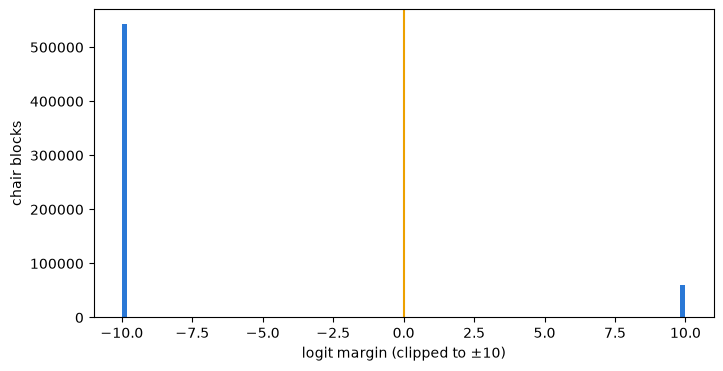

blocks with |score| < 1: 1,936 (0.3%)


state
hb    0.001
hh    0.001
sh    0.001
sl    0.001
bw    0.002
mv    0.002
nw    0.002
rp    0.002
by    0.003
th    0.003
ni    0.003
st    0.003
bb    0.004
be    0.004
he    0.004
sn    0.008
Name: score, dtype: float64

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(blocks["score"].clip(-10, 10), bins=100, color=NAVY)
ax.axvline(0, color=GOLD)
ax.set(xlabel="logit margin (clipped to ±10)", ylabel="chair blocks"); plt.show()
near = blocks["score"].abs() < 1
print(f"blocks with |score| < 1: {near.sum():,} ({near.mean():.1%})")
near.groupby(blocks["state"]).mean().sort_values().round(3)

## Spot checks

`show_protocol` lists a protocol's opener blocks (and, with `all_blocks=True`, every chair block) with their scores.

In [8]:
def show_protocol(protocol_id, all_blocks=False, chars=160):
    print(urls.get(protocol_id))
    rows = blocks[blocks["protocol_id"] == protocol_id].sort_values("start_pos")
    if not all_blocks:
        rows = rows[rows["is_opener_pred"] == 1]
    for _, row in rows.iterrows():
        mark = "TOP" if row["is_opener_pred"] else "   "
        print(f"{mark} {row['start_pos']:>5} {row['score']:6.2f}  {row['content'][:chars]!r}")

most = per.sort_values(ascending=False)
print(most.head(10).to_string())
show_protocol(most.index[0])

protocol_id
sn_7_30     78
sn_7_64     77
mv_6_123    64
nw_17_26    47
by_17_89    44
ni_17_49    39
sn_5_1      38
bb_6_66     37
bb_7_107    37
bb_7_108    36
https://assets.stateparl.de/protocols/sn_7_30.pdf
TOP   204   9.92  'Nach den Ausführungen von Herrn Staatsminister Günther kommen wir jetzt, meine sehr geehrten Damen und Herren, zur Abstimmung über den Einzelplan 09 – Staatsmin'
TOP   218   0.99  'Vielen Dank. Gibt es weiteren Redebedarf? – Das kann ich nicht erkennen. Ich stelle die Drucksache 7/6327 zur Abstimmung und bitte bei Zustimmung um das Handzei'
TOP   244   0.92  'Weiteren Redebedarf sehe ich jetzt nicht. Deshalb stelle ich die Drucksache 7/6357 zur Abstimmung und bitte bei Zustimmung um Ihr Handzeichen. – Danke. Gegensti'
TOP   256   5.67  'Ich sehe jetzt keinen weiteren Redebedarf. Ich stelle die Drucksache 7/6358 zur Abstimmung und bitte bei Zustimmung um Ihr Handzeichen. – Vielen Dank. Gegenstim'
TOP   278   9.42  'Da ich keinen weiteren Redebedarf sehe, stell

In [9]:
show_protocol(scored_none["protocol_id"].iloc[0], all_blocks=True)

https://assets.stateparl.de/protocols/bb_7_1.pdf
        1  -0.03  'Sehr geehrte Abgeordnete! Sehr geehrter Herr Ministerpräsident! Sehr geehrter Präsident des Verfassungsgerichts! Sehr geehrte ehemalige Abgeordnete! Sehr geehrt'
      135 -18.00  'Das tun Sie jetzt gleich? - Gut.\nDann schlage ich eine 30-minütige Pause vor, weil die neuen Wahlzettel vorbereitet werden müssen. Wir sehen uns dann um 13 Uhr '
      140  -3.98  'Ich frage meine beiden Vizepräsidenten, ob Sie diesem Vorschlag zustimmen. - Ja. Dann tun wir das.\nWir kommen zur geheimen Wahl über den Antrag mit Wahlvorschla'


In [10]:
show_protocol(per.sample(1, random_state=SEED).index[0])

https://assets.stateparl.de/protocols/hb_20_43.pdf


TOP     1  13.01  'Einen wunderschönen guten Morgen, meine sehr verehrten Damen und Herren, die 43. Sitzung der Bürgerschaft (Landtag) ist hiermit eröffnet. Ich begrüße die hier a'
TOP   405  10.99  'Weitere Wortmeldungen liegen nicht vor.\nDie Beratung ist geschlossen.\nWir kommen jetzt zu der Abstimmung über die Vorlagen zum Haushalt 2023.\nEs ist vereinbart '
TOP   550  12.48  'Weitere Wortmeldungen liegen nicht vor.\nDie Aussprache ist geschlossen.\nDie Bürgerschaft Landtag nimmt von der Antwort des Senats, Drucksache 20/1540, auf die G'
TOP   820  11.13  'Das erste Thema der Aktuellen Stunde ist beendet.\nIch rufe jetzt das zweite Thema auf.\nErgebnisse der Vergleichsarbeiten in Jahrgangsstufe 3 und 8 (VERA-3/-8): '
TOP  1195   3.13  'Meine sehr verehrten Damen und Herren, weitere Wortmeldungen liegen nicht vor. Wir haben damit das Ende der Aktuellen Stunde erreicht.\nInterfraktionell wurde ve'
TOP  1258  12.99  'Weitere Zusatzfragen sehe ich nicht. Ich bedanke mich für die Beantw